In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Comment Category Prediction Challenge

This project focuses on building a machine learning model to classify user-generated comments into predefined categories. The task is part of a competition where the goal is to achieve good performance on unseen data.

The dataset includes text comments along with additional features such as engagement metrics (upvotes, downvotes), emotion-related information, and topic-related attributes (race, religion, gender, disability).

The main objective is to develop a multi-class classification model that can use both text and other features to accurately predict the category of each comment.

# Data Loading and Initial Inspection

In [3]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [4]:
# Loading the datasets

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv") 

In [5]:
# Shape of dataset

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (198000, 15)
test shape: (102000, 14)


In [6]:
# Preview of training data

print("Train head:")
train.head()

Train head:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [7]:
# Preview of test data

print("Test head:")
test.head()

Test head:


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


# Exploratory Data Analysis

In [8]:
# Getting information of dataset

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


### Observation

- The dataset contains:
  - **9 numerical features**
  - **5 object (categorical/text) features**
  - **1 boolean feature (`disability`)**

In [9]:
# Descriptive statistics

train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


### Observation

- Most features such as `emoticon_1`, `emoticon_2`, and `emoticon_3` are highly skewed toward 0.
- `upvote` and `downvote` have a wide range, indicating variability in user engagement.
- Internal features (`if_1`, `if_2`) show large variance and may carry strong predictive signals.
- The target variable (`label`) ranges from 0 to 3.

In [10]:
# Missing values in the dataset

print(f"Missing values in train: {train.isnull().sum()}")
print(f"\nMissing values in test: {test.isnull().sum()}")

Missing values in train: created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Missing values in test: created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


### Observation

- A very high percentage (~73%) of missing values is present in:
  - `race`
  - `religion`
  - `gender`
- The `comment` column has negligible missing values and can be safely filled.

In [11]:
# Check for duplicates

print(f"Duplicate rows in train: {train.duplicated().sum()}")
print(f"Duplicate rows in test: {test.duplicated().sum()}")

Duplicate rows in train: 0
Duplicate rows in test: 0


In [12]:
# Feature types

categorical_cols = train.select_dtypes(include="object").columns
numerical_cols = train.select_dtypes(exclude="object").columns

print(f"Number of numerical features  : {len(numerical_cols)}")
print(f"Number of categorical features: {len(categorical_cols)}")

Number of numerical features  : 10
Number of categorical features: 5


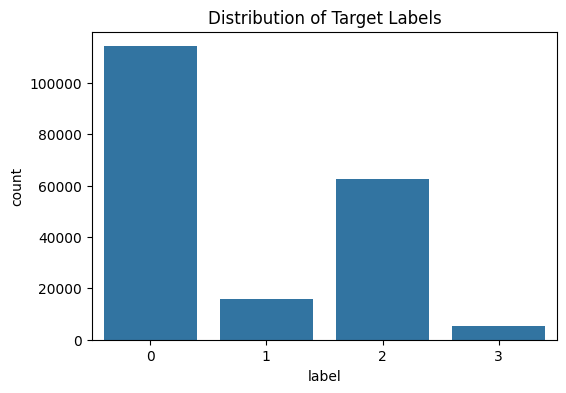

label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64

In [13]:
# Target variable distribution

plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train)
plt.title("Distribution of Target Labels")
plt.show()

train["label"].value_counts(normalize=True) * 100

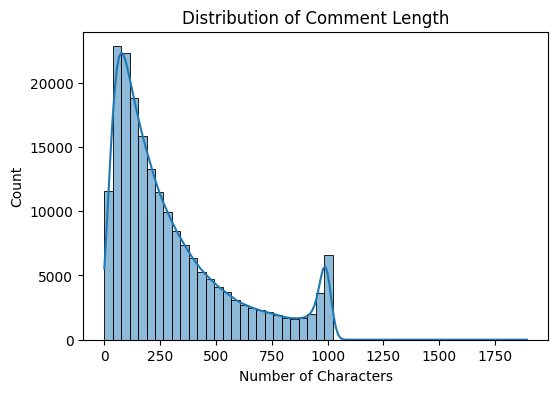

In [14]:
# Comment length analysis

train["temp_length"] = train["comment"].astype(str).apply(len)

plt.figure(figsize=(6,4))
sns.histplot(train["temp_length"], bins=50, kde=True)
plt.title("Distribution of Comment Length")
plt.xlabel("Number of Characters")
plt.show()

### Observation

- The distribution of comment length is **right-skewed**, meaning most comments are short.
- A large number of comments fall within the range of **0–300 characters**.
- A small number of comments are very long (up to ~1800 characters).
- This suggests that most user interactions are brief, but some comments contain detailed discussions.

/tmp/ipykernel_55/3167812585.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


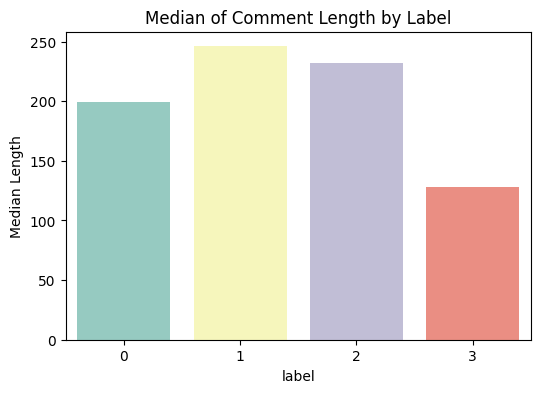

In [15]:
# Median comment length across different labels

length_stats = train.groupby("label")["temp_length"].median().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(
    x="label",
    y="temp_length",
    data=length_stats,
    palette="Set3"
)

plt.title("Median of Comment Length by Label")
plt.ylabel("Median Length")
plt.show()

### Observation

- Median comment length varies across different classes:
  - Class 1 has the **highest median length (~250)**
  - Class 2 also has relatively long comments
  - Class 0 has moderate length (~200)
  - Class 3 has the **shortest comments (~130)**

- This indicates that **comment length may be an important feature** for classification.

In [16]:
train.drop(columns=["temp_length"], inplace=True)

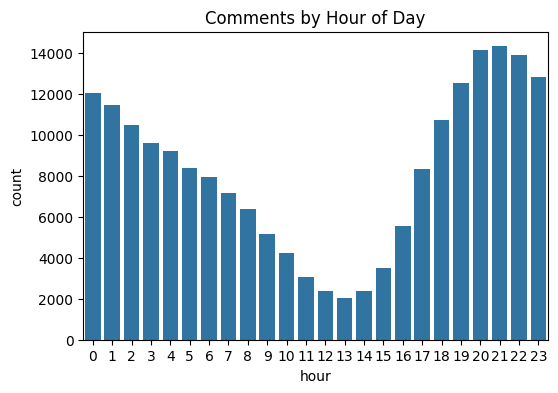

In [17]:
# Distribution of comments across hours of the day

train["created_date"] = pd.to_datetime(train["created_date"])

train["hour"] = train["created_date"].dt.hour

plt.figure(figsize=(6,4))
sns.countplot(x="hour", data=train)
plt.title("Comments by Hour of Day")
plt.show()

### Observation

- Comment activity varies significantly across different hours of the day. Peak activity is observed during **evening hours (around 18–23)** and the lowest activity occurs during **midday hours (around 11–14)**.

- This suggests that user engagement is time-dependent, and **hour of comment posting may be a useful feature** for prediction.

In [18]:
train.drop(columns=["hour"], inplace=True)

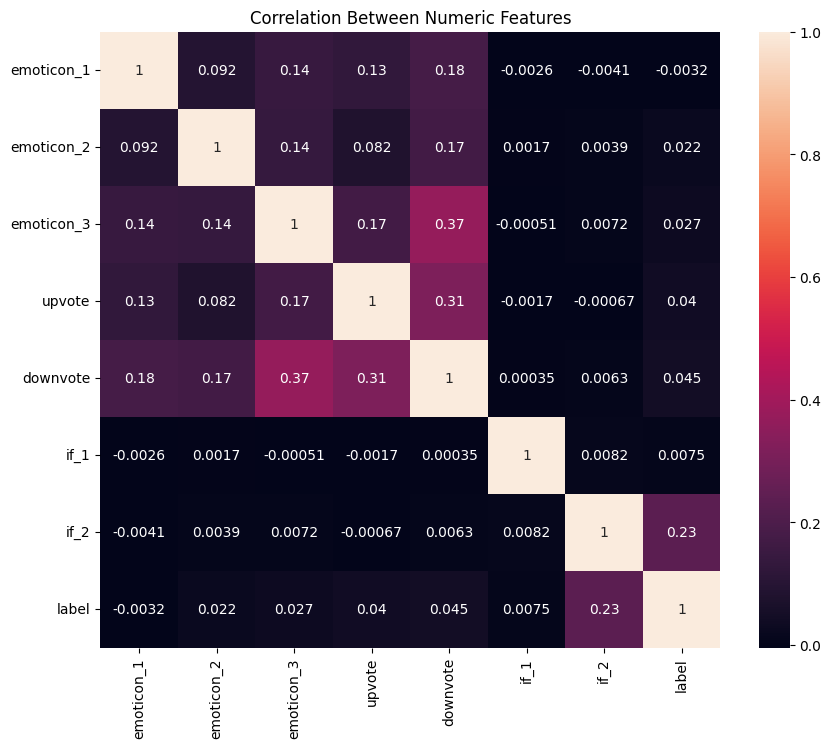

In [19]:
# Correlation Between Numeric Features

numeric_cols = train.select_dtypes(include=["int64"])
numeric_cols = numeric_cols.drop(columns=["post_id"])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True)
plt.title("Correlation Between Numeric Features")
plt.show()

### Observation

Most features show low correlation, indicating minimal multicollinearity. The target has weak correlation overall, with slight influence from `if_2`.

- This suggests that:
  - No single numerical feature strongly determines the label
  - The model will benefit from combining multiple features, especially text data

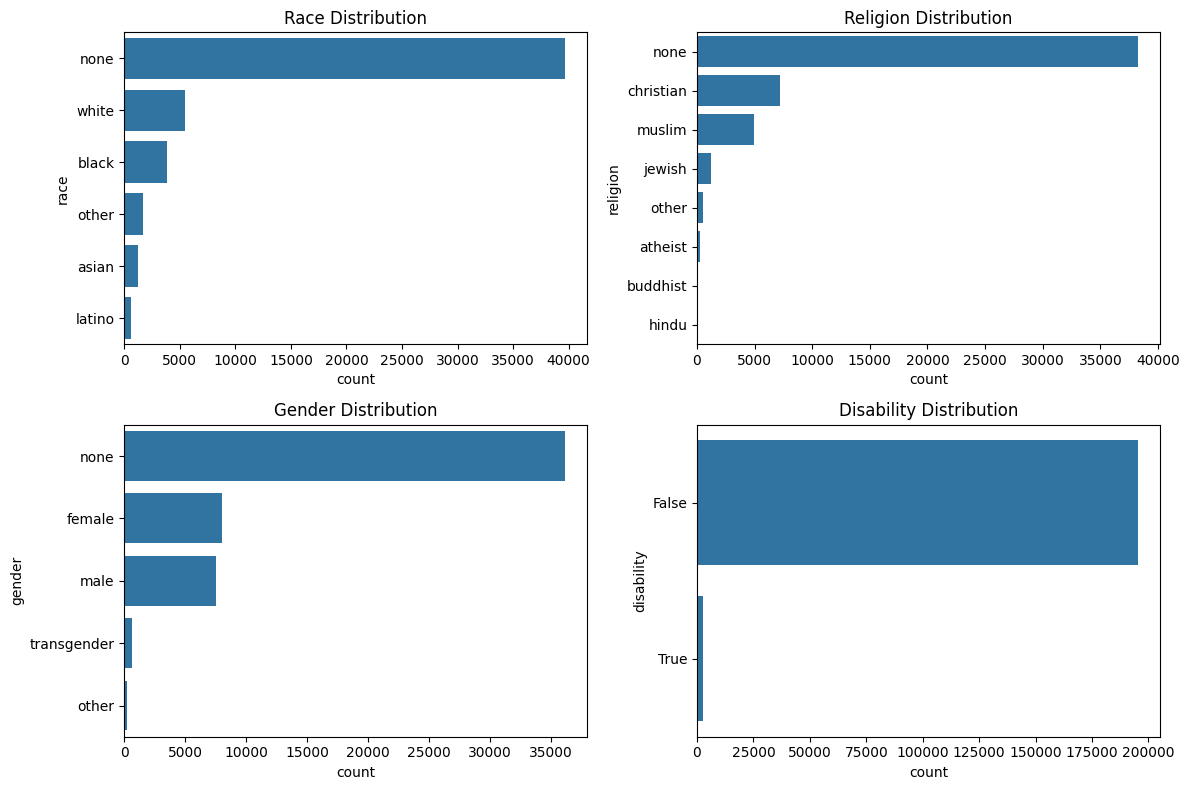

In [20]:
# Distribution visuals for Topic Columns

topic_cols = ["race", "religion", "gender", "disability"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col in enumerate(topic_cols):
    sns.countplot(y=col, data=train, order=train[col].value_counts().index, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f"{col.capitalize()} Distribution")

plt.tight_layout()
plt.show()

**Observation:**  

Most values are "none", and other categories have much lower counts. The `disability` feature is also highly imbalanced toward False.

- This imbalance suggests:
  - These features are **rare signals**
  - When present, they may strongly influence classification

- Proper encoding will be required to preserve these signals without introducing noise.

# Data Cleaning & Preprocessing 

In [21]:
# Handle missing values

# Fill comment column
train["comment"] = train["comment"].fillna("")
test["comment"] = test["comment"].fillna("")

# Fill topic columns
topic_cols = ["race", "religion", "gender"]
for col in topic_cols:
    train[col] = train[col].fillna("none")

topic_cols = ["race", "religion", "gender"]
for col in topic_cols:
    test[col] = test[col].fillna("none")

### Handling Missing Values

- The `comment` column has very few missing values, which are replaced with empty strings.
- The columns `race`, `religion`, and `gender` have a large number of missing values (~73%).
- These missing values are treated as **"none"**, indicating absence of such references rather than missing data.

In [22]:
# Convert bool to int

train["disability"] = train["disability"].astype(int)
test["disability"] = test["disability"].astype(int)

### Converting Boolean Features

- The `disability` column is converted from boolean to integer format.
- This ensures compatibility with machine learning models, which require numerical input.

In [23]:
# check...

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  198000 non-null  datetime64[ns, UTC]
 1   post_id       198000 non-null  int64              
 2   emoticon_1    198000 non-null  int64              
 3   emoticon_2    198000 non-null  int64              
 4   emoticon_3    198000 non-null  int64              
 5   upvote        198000 non-null  int64              
 6   downvote      198000 non-null  int64              
 7   if_1          198000 non-null  int64              
 8   if_2          198000 non-null  int64              
 9   race          198000 non-null  object             
 10  religion      198000 non-null  object             
 11  gender        198000 non-null  object             
 12  disability    198000 non-null  int64              
 13  comment       198000 non-null  object       

In [24]:
# Comment text cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train["comment"] = train["comment"].apply(clean_text)
test["comment"] = test["comment"].apply(clean_text)

### Text Cleaning

- Text data is preprocessed to remove noise and standardize format:
  - Convert text to lowercase
  - Remove URLs
  - Remove extra spaces

- This helps in improving the quality of text features before applying TF-IDF.

In [25]:
# Extract time features

# Convert to datetime
train["created_date"] = pd.to_datetime(train["created_date"])
test["created_date"] = pd.to_datetime(test["created_date"])

# Extract hour and dayofweek
train["hour"] = train["created_date"].dt.hour
train["dayofweek"] = train["created_date"].dt.dayofweek

test["hour"] = test["created_date"].dt.hour
test["dayofweek"] = test["created_date"].dt.dayofweek

# Drop original date column
train.drop(columns=["created_date"], inplace=True)
test.drop(columns=["created_date"], inplace=True)

### Time-Based Feature Engineering

- The `created_date` column is converted into datetime format.
- New features are extracted:
  - `hour` → hour of the day
  - `dayofweek` → day of the week

- These features help capture temporal patterns in user activity.
- The original `created_date` column is dropped after extraction.

In [26]:
# Structural text features

train["comment_length"] = train["comment"].apply(len)
train["word_count"] = train["comment"].apply(lambda x: len(x.split()))
train["avg_word_length"] = train["comment_length"] / (train["word_count"] + 1)

test["comment_length"] = test["comment"].apply(len)
test["word_count"] = test["comment"].apply(lambda x: len(x.split()))
test["avg_word_length"] = test["comment_length"] / (test["word_count"] + 1)

### Structural Text Features

Additional features are created from the comment text:

- `comment_length` → total number of characters
- `word_count` → number of words
- `avg_word_length` → average length of words

These features provide insights into the structure and complexity of comments, which may help in classification.

In [27]:
# define feature groups

text_feature = "comment"

categorical_features = ["race", "religion", "gender"]

numeric_features = [
    "upvote", "downvote", "if_1", "if_2",
    "hour", "dayofweek",
    "emoticon_1", "emoticon_2", "emoticon_3",
    "disability", "comment_length",
    "word_count", "avg_word_length"
]

### Feature Categorization

Features are divided into three groups:

- **Text feature**:
  - `comment`

- **Categorical features**:
  - race, religion, gender

- **Numerical features**:
  - engagement metrics, internal features, time features, and engineered text features

This separation is important for applying appropriate preprocessing techniques.

In [28]:
# Text pipeline

text_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30000,
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
        stop_words="english",
    ))
])


# Categorical pipeline

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# Numerical pipeline

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [29]:
# Combine pipelines

preprocessor = ColumnTransformer([
    ("text", text_pipeline, text_feature),
    ("cat", cat_pipeline, categorical_features),
    ("num", num_pipeline, numeric_features)
])

### Feature Processing Pipeline

- **Text (TF-IDF):** Converts comments into numerical features using unigrams and bigrams (max 30,000 features), capturing meaningful word patterns while reducing noise.  
- **Categorical:** One-hot encoding is applied, with unknown categories handled safely.  
- **Numerical:** Features are scaled using StandardScaler for balanced contribution.  

All transformations are combined using a **ColumnTransformer**, ensuring a unified and consistent preprocessing pipeline.

In [30]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = train.drop(columns="label")
y = train["label"]

# Train-validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Model building and Evaluation

## Model 1 - SVM

In [31]:
# Build SVM pipeline

svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearSVC(
        C=0.1,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

In [32]:
# Train model

svm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_df=0.9,
                                                                                   max_features=30000,
                                                                                   min_df=3,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'comment'),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'hour', 'dayofweek',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'disability',
                                                   'comment_length',
                                                   'word_count',
                                                   'avg_word_length'])])),
                ('classifier',
                 LinearSVC(C=0.1, class_weight='balanced', max_iter=3000,
                           random_state=42))])

In [33]:
# Train evaluation

y_pred_svm_train = svm_model.predict(X_train)

print("SVM Train Performance")
print(classification_report(y_train, y_pred_svm_train))
print("Train Macro F1:", f1_score(y_train, y_pred_svm_train, average="macro"))

SVM Train Performance
              precision    recall  f1-score   support

           0       0.88      0.89      0.88     91338
           1       0.69      0.86      0.77     12735
           2       0.86      0.75      0.80     49952
           3       0.58      0.89      0.70      4375

    accuracy                           0.84    158400
   macro avg       0.75      0.85      0.79    158400
weighted avg       0.85      0.84      0.84    158400

Train Macro F1: 0.7875555811721241


In [34]:
# Evaluate model

y_pred_svm = svm_model.predict(X_val)

print("SVM Validation Performance")
print(classification_report(y_val, y_pred_svm))
print("Macro F1 Score:", f1_score(y_val, y_pred_svm, average="macro"))

SVM Validation Performance
              precision    recall  f1-score   support

           0       0.84      0.87      0.86     22835
           1       0.64      0.78      0.70      3183
           2       0.81      0.68      0.74     12488
           3       0.44      0.63      0.52      1094

    accuracy                           0.80     39600
   macro avg       0.68      0.74      0.70     39600
weighted avg       0.81      0.80      0.80     39600

Macro F1 Score: 0.7048011667707366


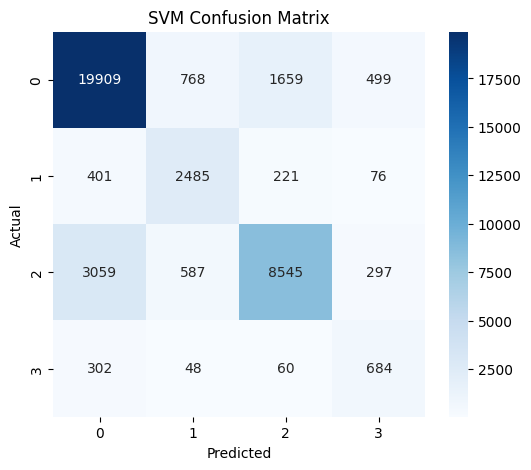

In [35]:
# Confusion matrix

cm_svm = confusion_matrix(y_val, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 2 - Logistic Regressiom

In [36]:
# Build Logistic Regression pipeline

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=42
    ))
])

In [37]:
# Train model

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_df=0.9,
                                                                                   max_features=30000,
                                                                                   min_df=3,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'comment'),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender']),
                                                 ('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'hour', 'dayofweek',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'disability',
                                                   'comment_length',
                                                   'word_count',
                                                   'avg_word_length'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, random_state=42,
                                    solver='saga'))])

In [38]:
# Train evaluation

y_pred_lr_train = lr_model.predict(X_train)

print("Logistic Regression Train Performance")
print(classification_report(y_train, y_pred_lr_train))
print("Train Macro F1:", f1_score(y_train, y_pred_lr_train, average="macro"))

Logistic Regression Train Performance
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     91338
           1       0.70      0.85      0.77     12735
           2       0.89      0.82      0.85     49952
           3       0.46      0.89      0.60      4375

    accuracy                           0.89    158400
   macro avg       0.75      0.87      0.79    158400
weighted avg       0.91      0.89      0.90    158400

Train Macro F1: 0.7933282958804673


In [39]:
# Evaluate model

y_pred_lr = lr_model.predict(X_val)

print("Logistic Regression Validation Performance")
print(classification_report(y_val, y_pred_lr))
print("Macro F1:", f1_score(y_val, y_pred_lr, average="macro"))

Logistic Regression Validation Performance
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     22835
           1       0.67      0.83      0.74      3183
           2       0.89      0.81      0.85     12488
           3       0.42      0.80      0.55      1094

    accuracy                           0.88     39600
   macro avg       0.73      0.84      0.77     39600
weighted avg       0.90      0.88      0.89     39600

Macro F1: 0.771062937767415


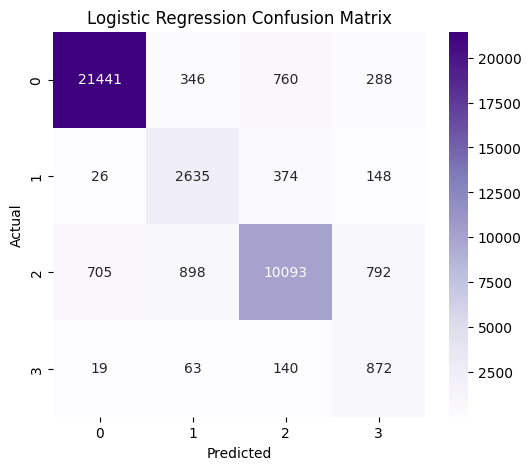

In [40]:
# confusion matrix

cm_lr = confusion_matrix(y_val, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Purples")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 3 – LightGBM

In [55]:
# Build LGBM pipeline

lgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        objective="multiclass",
        num_class=4,
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=120,
        lambda_l2=1.0,
        class_weight={
            0: 1,
            1: 1.5,
            2: 1,
            3: 2
        },
        random_state=42,
        n_jobs=-1
    ))
])

In [56]:
# Train model

lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 4.793577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 613828
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 5052
[LightGBM] [Info] Start training from score -0.616175
[LightGBM] [Info] Start training from score -2.180922
[LightGBM] [Info] Start training from score -1.219679
[LightGBM] [Info] Start training from score -2.961688


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_df=0.9,
                                                                                   max_features=30000,
                                                                                   min_df=3,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'comment'),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender']),
                                                 ('num',
                                                  Pipeline(steps...
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'hour', 'dayofweek',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'disability',
                                                   'comment_length',
                                                   'word_count',
                                                   'avg_word_length'])])),
                ('classifier',
                 LGBMClassifier(class_weight={0: 1, 1: 1.5, 2: 1, 3: 2},
                                lambda_l2=1.0, learning_rate=0.03,
                                min_child_samples=120, n_estimators=600,
                                n_jobs=-1, num_class=4, objective='multiclass',
                                random_state=42))])

In [57]:
# Train evaluation

y_pred_lgb_train = lgb_model.predict(X_train)

print("LightGBM Train Performance")
print(classification_report(y_train, y_pred_lgb_train))
print("Train Macro F1:", f1_score(y_train, y_pred_lgb_train, average="macro"))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
LightGBM Train Performance
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     91338
           1       0.81      0.86      0.83     12735
           2       0.88      0.92      0.90     49952
           3       0.78      0.70      0.73      4375

    accuracy                           0.93    158400
   macro avg       0.86      0.86      0.86    158400
weighted avg       0.93      0.93      0.93    158400

Train Macro F1: 0.8578961851416738


In [58]:
# Evaluate model

y_pred_lgb = lgb_model.predict(X_val)

print("LightGBM Validation Performance")
print(classification_report(y_val, y_pred_lgb))
print("Macro F1:", f1_score(y_val, y_pred_lgb, average="macro"))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
LightGBM Validation Performance
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.75      0.81      0.78      3183
           2       0.86      0.90      0.88     12488
           3       0.68      0.58      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.82      0.81      0.81     39600
weighted avg       0.92      0.91      0.91     39600

Macro F1: 0.812152626001102


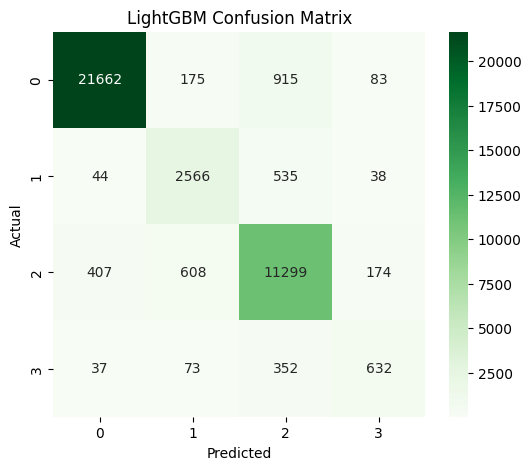

In [59]:
# Confusion matrix

cm_lgb = confusion_matrix(y_val, y_pred_lgb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Greens")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
# Model comparison

results = pd.DataFrame({
    "Model": ["SVM","LogisticRegression", "LightGBM"],
    "Macro F1": [
        f1_score(y_val, y_pred_svm, average="macro"),
        f1_score(y_val, y_pred_lr, average="macro"),
        f1_score(y_val, y_pred_lgb, average="macro"),
    ]
})

results

,Model,Macro F1
0,SVM,0.704801
1,LogisticRegression,0.771063
2,LightGBM,0.812153


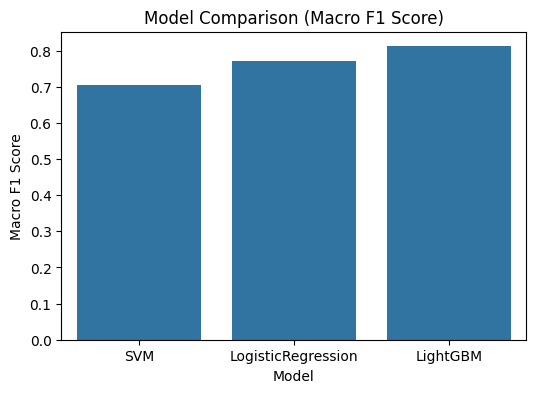

In [61]:
# Visual comparison of model performance

plt.figure(figsize=(6,4))

sns.barplot(
    x="Model",
    y="Macro F1",
    data=results
)

plt.title("Model Comparison (Macro F1 Score)")
plt.ylabel("Macro F1 Score")
plt.xlabel("Model")

plt.show()

## Model Evaluation Summary

Three models were trained and evaluated using Macro F1 Score:

- **SVM** showed lower performance (~0.70) and struggled with minority classes.
- **Logistic Regression** performed better (~0.77) with improved generalization but still had limitations in handling class imbalance.
- **LightGBM** achieved the best performance (~0.82), effectively capturing complex patterns and handling imbalanced data.

Overall, LightGBM outperformed the linear models and was selected as the final model for this task.

# Hyperparameter Tuning

In [62]:
# define parameter distribution


param_dist = {
    "classifier__n_estimators": [350, 400, 450],
    "classifier__learning_rate": [0.04, 0.05],
    "classifier__num_leaves": [50, 63, 80]
}

In [63]:
# Setup for RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=param_dist,
    n_iter=2,
    scoring="f1_macro",
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [64]:
# Tune hyperparameters

random_search.fit(X_train, y_train)

Fitting 2 folds for each of 2 candidates, totalling 4 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.697676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 313735
[LightGBM] [Info] Number of data points in the train set: 79200, number of used features: 2798
[LightGBM] [Info] Start training from score -0.616178
[LightGBM] [Info] Start training from score -2.181004
[LightGBM] [Info] Start training from score -1.219682
[LightGBM] [Info] Start training from score -2.961462
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.666186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 613828
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 5052
[LightGBM] [Info] Start training from score -0.616175
[LightGBM] [Info] Start training from score -2.180922
[LightGBM] [Info] Start training from score -1.219679
[LightGBM] [Info] Start training from score -2.961688
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of 

RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('text',
                                                                               Pipeline(steps=[('tfidf',
                                                                                                TfidfVectorizer(max_df=0.9,
                                                                                                                max_features=30000,
                                                                                                                min_df=3,
                                                                                                                ngram_range=(1,
                                                                                                                             2),
                                                                                                                stop_words='english',
                                                                                                                sublinear_tf=True))]),
                                                                               'comment'),
                                                                              ('cat',
                                                                               Pipeline(steps=[('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['race',
                                                                                'religion...
                                                                           1: 1.5,
                                                                           2: 1,
                                                                           3: 2},
                                                             lambda_l2=1.0,
                                                             learning_rate=0.03,
                                                             min_child_samples=120,
                                                             n_estimators=600,
                                                             n_jobs=-1,
                                                             num_class=4,
                                                             objective='multiclass',
                                                             random_state=42))]),
                   n_iter=2, n_jobs=-1,
                   param_distributions={'classifier__learning_rate': [0.04,
                                                                      0.05],
                                        'classifier__n_estimators': [350, 400,
                                                                     450],
                                        'classifier__num_leaves': [50, 63, 80]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [67]:
# Show best parameters

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Parameters: {'classifier__num_leaves': 63, 'classifier__n_estimators': 350, 'classifier__learning_rate': 0.04}
Best CV Score: 0.7959336416072591


In [68]:
# Evaluate tuned model

best_lgb = random_search.best_estimator_

y_pred_tuned = best_lgb.predict(X_val)

print("Tuned LightGBM Performance")
print(classification_report(y_val, y_pred_tuned))
print("Macro F1:", f1_score(y_val, y_pred_tuned, average="macro"))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
Tuned LightGBM Performance
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.74      0.81      0.77      3183
           2       0.87      0.90      0.88     12488
           3       0.67      0.60      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.81      0.81      0.81     39600
weighted avg       0.92      0.91      0.91     39600

Macro F1: 0.8132310762882955


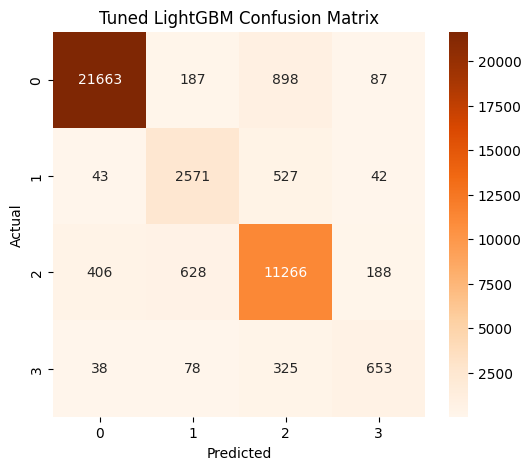

In [69]:
# Confusion matrix

cm_lgb_tuned = confusion_matrix(y_val, y_pred_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lgb_tuned, annot=True, fmt="d", cmap="Oranges")
plt.title("Tuned LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Hyperparameter Tuning Summary

Hyperparameter tuning was performed on the LightGBM model using RandomizedSearchCV to explore different parameter combinations efficiently.

- Best CV Score: ~0.80  
- Best Parameters included optimized values for number of estimators, learning rate, and number of leaves.

However, the tuned model did not outperform the manually configured LightGBM model on validation data.

Therefore, the manually tuned LightGBM model was selected as the final model for submission, as it provided better performance and generalization.

# Final Submission

In [70]:
# Final Model Training

lgb_model.fit(X, y)

[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 7.843136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 751830
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 6081
[LightGBM] [Info] Start training from score -0.616170
[LightGBM] [Info] Start training from score -2.180969
[LightGBM] [Info] Start training from score -1.219678
[LightGBM] [Info] Start training from score -2.961642


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_df=0.9,
                                                                                   max_features=30000,
                                                                                   min_df=3,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'comment'),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['race', 'religion',
                                                   'gender']),
                                                 ('num',
                                                  Pipeline(steps...
                                                  ['upvote', 'downvote', 'if_1',
                                                   'if_2', 'hour', 'dayofweek',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'disability',
                                                   'comment_length',
                                                   'word_count',
                                                   'avg_word_length'])])),
                ('classifier',
                 LGBMClassifier(class_weight={0: 1, 1: 1.5, 2: 1, 3: 2},
                                lambda_l2=1.0, learning_rate=0.03,
                                min_child_samples=120, n_estimators=600,
                                n_jobs=-1, num_class=4, objective='multiclass',
                                random_state=42))])

In [71]:
# Predict on Test Data

test_predictions = lgb_model.predict(test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0


In [72]:
# Create Submission CSV file

submission = sample.copy()
submission["label"] = test_predictions
submission.to_csv("submission.csv", index=False)

In [73]:
submission.head()

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
